# UZS: разведочный анализ и point-in-time фичи

Цель notebook — быстро проверить качество ряда ЦБ по узбекскому суму, построить интерпретируемые признаки и сделать первичный sanity-check сигналов. Это **не финальный walk-forward backtest**: будущие значения используются только в блоке оценки/разметки, но не при построении признаков и сигналов.

Рабочая величина: `rub_per_uzs = curs / nominal` — рублей за один UZS. Для отправителя **меньше = выгоднее**. Для продуктовой интерпретации дополнительно считаем `uzs_per_rub = 1 / rub_per_uzs` — сколько UZS получает адресат за один рубль.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dbfread import DBF

Notebook использует только длинный публичный ряд ЦБ по UZS. Все окна и производные считаются после сортировки дат по возрастанию.

In [2]:
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)
plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_SEED = 30
DATA_PATH = Path('data/UZS_RC_F02_09_2016_T02_09_2026.dbf')
assert DATA_PATH.exists(), f'Файл не найден: {DATA_PATH.resolve()}'

## 1. Загрузка и аудит данных

Важно использовать длинный файл `F02_09_2016_T02_09_2026`. Короткий файл `UZS_RC_F26_08_2026_T02_09_2026.dbf` в репозитории выглядит ошибочным и фактически содержит USD, поэтому здесь он исключён.

In [3]:
raw = pd.DataFrame(iter(DBF(DATA_PATH, encoding='cp1251')))
raw.columns = [c.lower() for c in raw.columns]
raw['data'] = pd.to_datetime(raw['data'])
raw['curs'] = pd.to_numeric(raw['curs'], errors='coerce')
raw['nominal'] = pd.to_numeric(raw['nominal'], errors='coerce')

audit = pd.Series({
    'rows': len(raw),
    'date_min': raw['data'].min().date(),
    'date_max': raw['data'].max().date(),
    'duplicate_dates': int(raw['data'].duplicated().sum()),
    'missing_required': int(raw[['data', 'curs', 'nominal']].isna().sum().sum()),
    'source_sorted_ascending': bool(raw['data'].is_monotonic_increasing),
    'source_sorted_descending': bool(raw['data'].is_monotonic_decreasing),
    'nominals': sorted(raw['nominal'].dropna().unique().tolist()),
})
display(audit.to_frame('value'))
display(raw.head(3))

,value
rows,2468
date_min,2016-09-02
date_max,2026-09-02
duplicate_dates,0
missing_required,0
source_sorted_ascending,False
source_sorted_descending,True
nominals,"[1000, 10000]"


,nominal,data,curs,cdx
0,10000,2026-09-02,73.3921,Узбекский сум
1,10000,2026-09-01,73.0760,Узбекский сум
2,10000,2026-08-29,72.5354,Узбекский сум


In [4]:
df = (raw
      .dropna(subset=['data', 'curs', 'nominal'])
      .drop_duplicates(subset='data', keep='last')
      .sort_values('data')
      .reset_index(drop=True))

df['rub_per_uzs'] = df['curs'] / df['nominal']
df['uzs_per_rub'] = 1.0 / df['rub_per_uzs']
df['calendar_gap_days'] = df['data'].diff().dt.days

quality = pd.Series({
    'rows_after_cleaning': len(df),
    'dates_are_ascending': bool(df['data'].is_monotonic_increasing),
    'min_calendar_gap': df['calendar_gap_days'].min(),
    'median_calendar_gap': df['calendar_gap_days'].median(),
    'max_calendar_gap': df['calendar_gap_days'].max(),
    'share_gaps_gt_1_day': (df['calendar_gap_days'] > 1).mean(),
})
display(quality.to_frame('value'))
display(df.loc[df['nominal'].ne(df['nominal'].shift()), ['data', 'nominal', 'curs', 'rub_per_uzs']])

,value
rows_after_cleaning,2468
dates_are_ascending,True
min_calendar_gap,1.0
median_calendar_gap,1.0
max_calendar_gap,13.0
share_gaps_gt_1_day,0.210292


,data,nominal,curs,rub_per_uzs
0,2016-09-02,1000,21.8249,0.021825
250,2017-09-06,10000,71.4201,0.007142
1354,2022-03-04,1000,10.2643,0.010264
1355,2022-03-05,10000,97.0734,0.009707
1357,2022-03-10,1000,10.6526,0.010653
1362,2022-03-17,10000,98.5216,0.009852


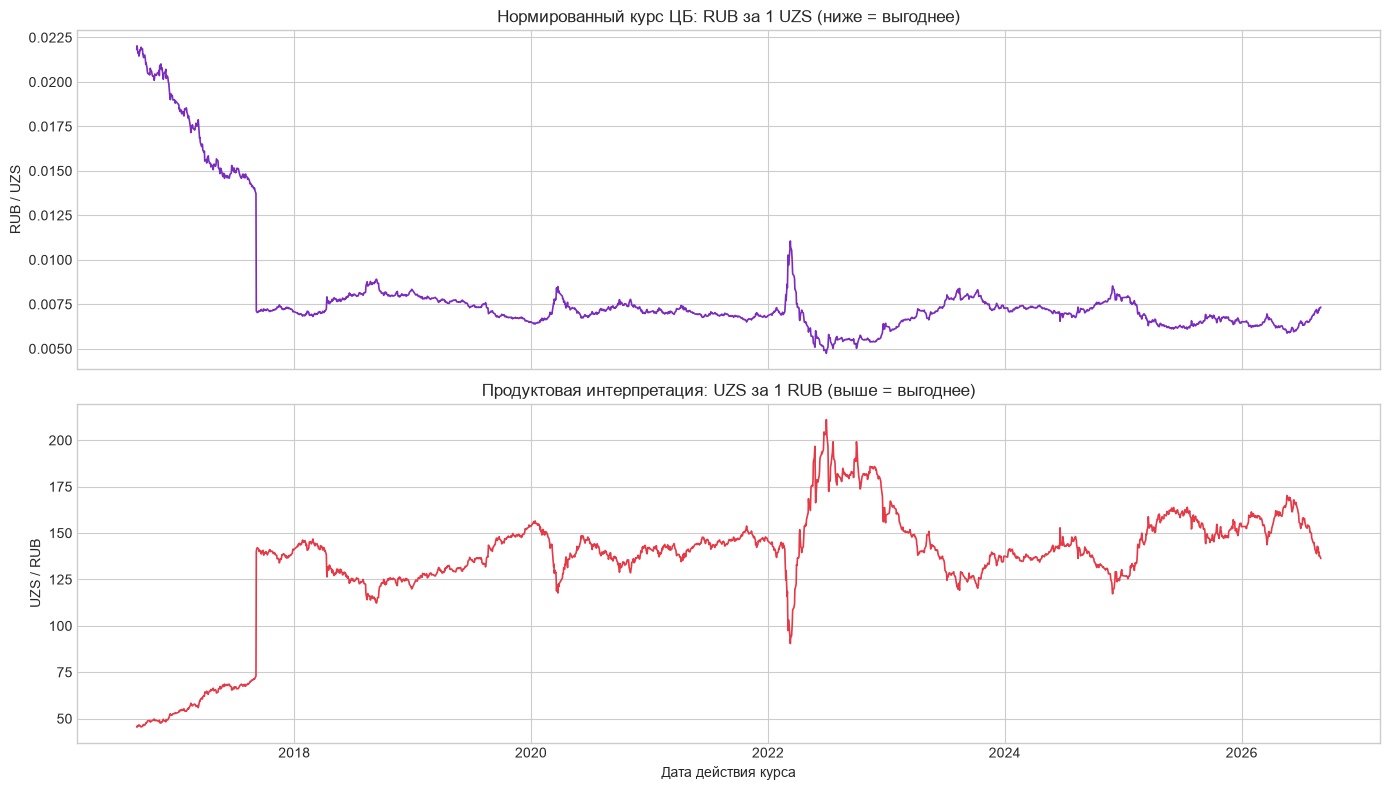

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(df['data'], df['rub_per_uzs'], lw=1.2, color='#7B2CBF')
axes[0].set_title('Нормированный курс ЦБ: RUB за 1 UZS (ниже = выгоднее)')
axes[0].set_ylabel('RUB / UZS')
axes[1].plot(df['data'], df['uzs_per_rub'], lw=1.2, color='#E63946')
axes[1].set_title('Продуктовая интерпретация: UZS за 1 RUB (выше = выгоднее)')
axes[1].set_ylabel('UZS / RUB')
axes[1].set_xlabel('Дата действия курса')
plt.tight_layout()
plt.show()

## 2. Point-in-time признаки

Все признаки ниже используют текущую и прошлые строки. Для производных считаются две версии:

- `d1_step` / `d2_step` — изменение на одну публикацию ЦБ;
- `d1_per_day` / `d2_per_day2` — изменение с поправкой на число календарных дней между публикациями;
- `ewm_*` — сглаженные производные, потому что вторая разность сырого дневного ряда очень шумная.

In [6]:
rate = df['rub_per_uzs']
dt = df['calendar_gap_days'].replace(0, np.nan)

# Первая и вторая производные
df['d1_step'] = rate.diff()
df['d1_pct'] = rate.pct_change(fill_method=None)
df['d1_per_day'] = rate.diff() / dt
df['d2_step'] = df['d1_step'].diff()
df['d2_per_day2'] = df['d1_per_day'].diff() / ((dt + dt.shift(1)) / 2)
df['rate_ewm_5'] = rate.ewm(span=5, adjust=False).mean()
df['ewm_d1_pct'] = df['rate_ewm_5'].pct_change(fill_method=None)
df['ewm_d2_pct'] = df['ewm_d1_pct'].diff()

# Momentum / returns
for window in (3, 5, 10, 20):
    df[f'return_{window}'] = rate.pct_change(window, fill_method=None)

# Уровень, расстояние до экстремумов и исторический percentile текущей точки
for window in (20, 60, 120):
    roll = rate.rolling(window, min_periods=window)
    roll_min = roll.min()
    roll_max = roll.max()
    df[f'level_pct_{window}'] = roll.apply(lambda x: np.mean(x <= x[-1]), raw=True)
    df[f'dist_to_min_{window}'] = rate / roll_min - 1
    df[f'dist_to_max_{window}'] = rate / roll_max - 1
    df[f'zscore_{window}'] = (rate - roll.mean()) / roll.std(ddof=0)

# Волатильность и режим
for window in (5, 10, 20, 60):
    df[f'vol_{window}'] = df['d1_pct'].rolling(window, min_periods=window).std(ddof=0)
df['vol_ratio_5_20'] = df['vol_5'] / df['vol_20']
df['range_20'] = rate.rolling(20, min_periods=20).max() / rate.rolling(20, min_periods=20).min() - 1

# Серия последовательных благоприятных движений: RUB/UZS снижается
is_down = df['d1_step'].lt(0)
df['down_streak'] = is_down.groupby((~is_down).cumsum()).cumsum().astype(int)

# Календарные признаки — не сигналы сами по себе, а кандидаты для модели
df['day_of_week'] = df['data'].dt.dayofweek
df['month'] = df['data'].dt.month
df['day_of_month'] = df['data'].dt.day

feature_columns = [c for c in df.columns if c not in raw.columns and c not in {'rub_per_uzs', 'uzs_per_rub'}]
print(f'Построено признаков: {len(feature_columns)}')
display(df[['data', 'rub_per_uzs', 'd1_pct', 'd2_step', 'ewm_d1_pct', 'ewm_d2_pct',
            'return_5', 'level_pct_60', 'dist_to_min_60', 'vol_20', 'down_streak']].tail(10))

Построено признаков: 35


,data,rub_per_uzs,d1_pct,d2_step,ewm_d1_pct,ewm_d2_pct,return_5,level_pct_60,dist_to_min_60,vol_20,down_streak
2458,2026-08-20,0.007202,0.002712,-0.000014,0.005365,-0.001353,0.031718,1.000000,0.219115,0.005049,0
2459,2026-08-21,0.007067,-0.018724,-0.000154,-0.002750,-0.008116,0.007582,0.933333,0.194247,0.006926,1
2460,2026-08-22,0.006999,-0.009595,0.000067,-0.005019,-0.002269,-0.011694,0.900000,0.182788,0.007559,2
2461,2026-08-25,0.007026,0.003880,0.000095,-0.002083,0.002937,-0.017190,0.916667,0.179793,0.007551,0
2462,2026-08-26,0.007171,0.020577,0.000117,0.005439,0.007522,-0.001593,0.966667,0.204069,0.008381,0
2463,2026-08-27,0.007156,-0.002149,-0.000160,0.002882,-0.002557,-0.006433,0.950000,0.201482,0.008429,1
2464,2026-08-28,0.007270,0.015943,0.000129,0.007261,0.004379,0.028668,1.000000,0.220637,0.008766,0
2465,2026-08-29,0.007254,-0.002216,-0.000130,0.004056,-0.003204,0.036333,0.983333,0.217932,0.008805,1
2466,2026-09-01,0.007308,0.007453,0.000070,0.005198,0.001141,0.040020,1.000000,0.227009,0.008829,0
2467,2026-09-02,0.007339,0.004326,-0.000022,0.004904,-0.000294,0.023460,1.000000,0.232317,0.008335,0


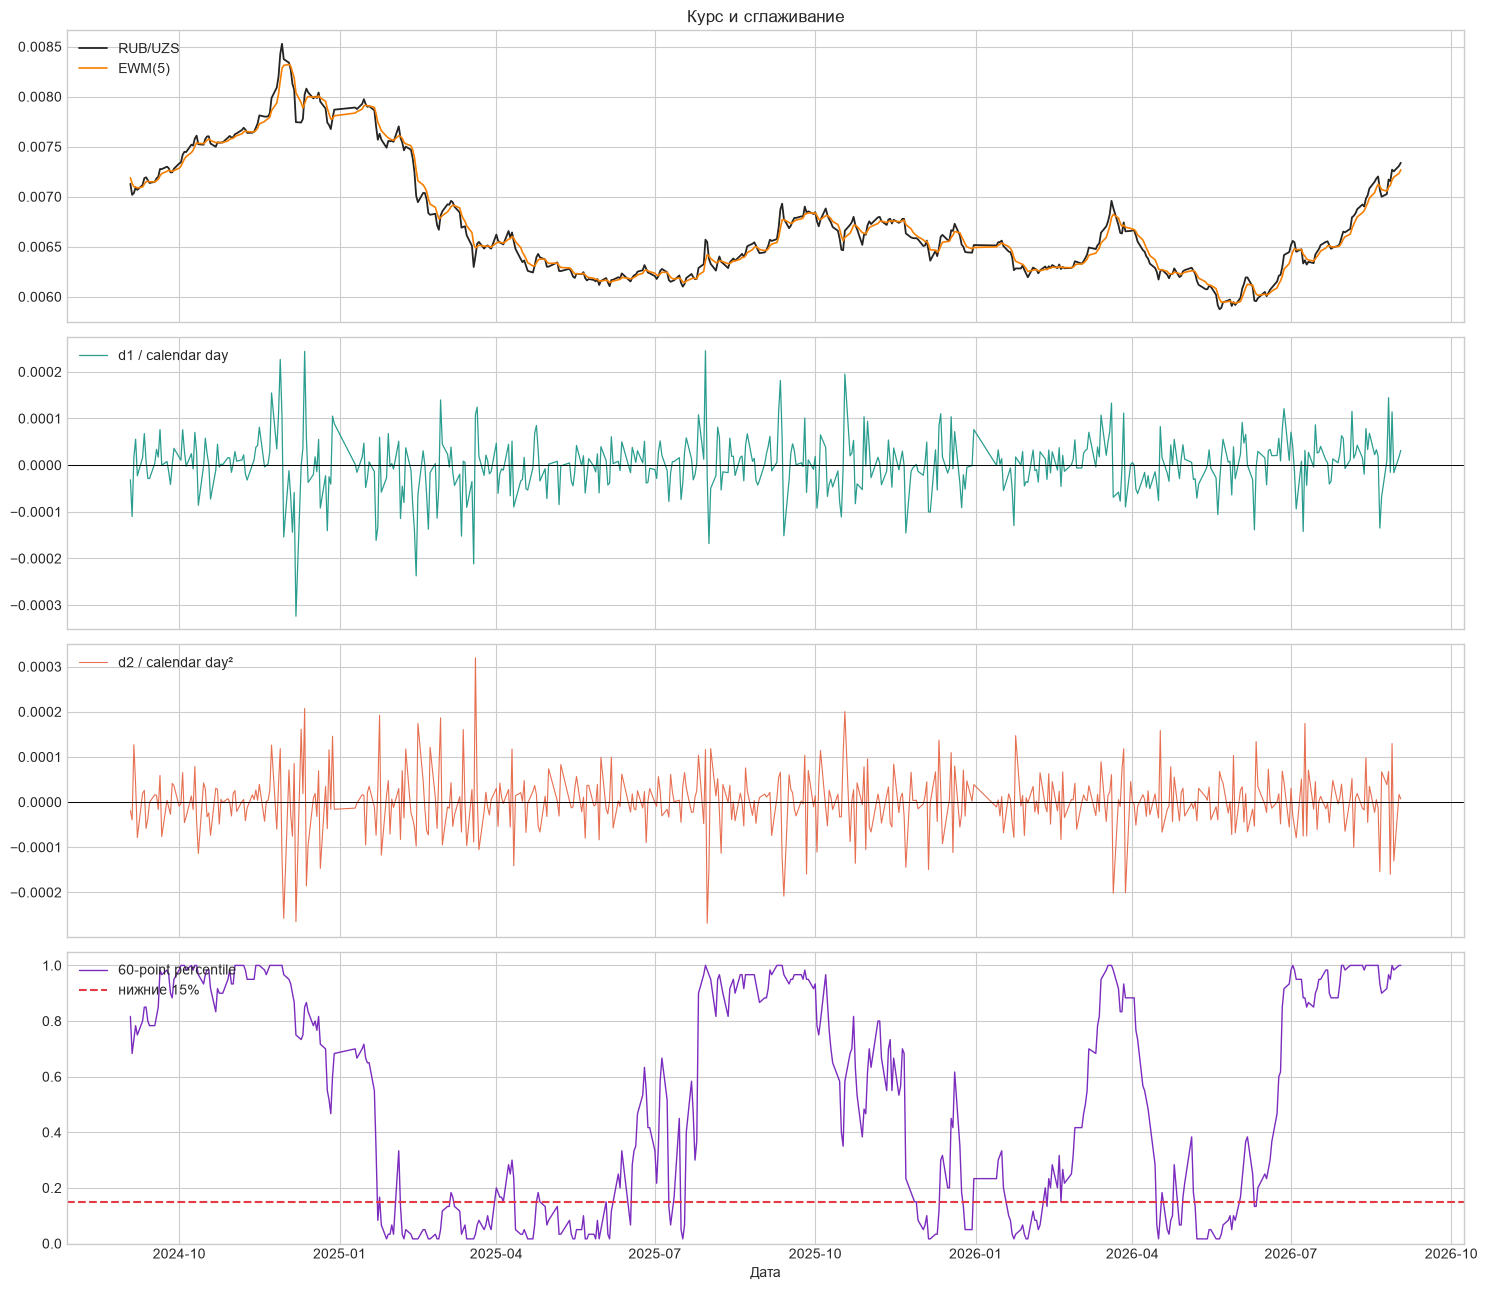

In [7]:
recent = df[df['data'] >= df['data'].max() - pd.DateOffset(years=2)].copy()
fig, axes = plt.subplots(4, 1, figsize=(15, 13), sharex=True)
axes[0].plot(recent['data'], recent['rub_per_uzs'], color='#252422', lw=1.3, label='RUB/UZS')
axes[0].plot(recent['data'], recent['rate_ewm_5'], color='#F77F00', lw=1.2, label='EWM(5)')
axes[0].legend(loc='upper left')
axes[0].set_title('Курс и сглаживание')
axes[1].plot(recent['data'], recent['d1_per_day'], color='#2A9D8F', lw=0.9, label='d1 / calendar day')
axes[1].axhline(0, color='black', lw=0.7)
axes[1].legend(loc='upper left')
axes[2].plot(recent['data'], recent['d2_per_day2'], color='#E76F51', lw=0.8, label='d2 / calendar day²')
axes[2].axhline(0, color='black', lw=0.7)
axes[2].legend(loc='upper left')
axes[3].plot(recent['data'], recent['level_pct_60'], color='#7B2CBF', lw=1.0, label='60-point percentile')
axes[3].axhline(0.15, color='#E63946', ls='--', label='нижние 15%')
axes[3].set_ylim(0, 1.05)
axes[3].legend(loc='upper left')
axes[3].set_xlabel('Дата')
plt.tight_layout()
plt.show()

## 3. Простые кандидаты на сигналы

Сигналы ниже нужны для разведки и интерпретации. Их пороги нельзя считать финально откалиброванными: финальная версия должна выбирать пороги только внутри train/calibration fold.

In [8]:
# Исторические пороги волатильности/скорости, рассчитанные только по прошлому окну
df['past_fast_drop_q15'] = df['ewm_d1_pct'].rolling(252, min_periods=126).quantile(0.15).shift(1)
df['past_vol_q80'] = df['vol_20'].rolling(252, min_periods=126).quantile(0.80).shift(1)

df['sig_level'] = df['level_pct_60'].le(0.15)
df['sig_momentum'] = df['down_streak'].ge(3) & df['return_5'].lt(0)
df['sig_derivative'] = (df['ewm_d1_pct'] <= df['past_fast_drop_q15']) & df['level_pct_60'].le(0.35)
df['sig_acceleration'] = (df['level_pct_60'].le(0.25) &
                          df['ewm_d1_pct'].lt(0) &
                          df['ewm_d2_pct'].gt(0))
df['sig_combined'] = (df['level_pct_60'].le(0.20) &
                      df['return_5'].lt(0) &
                      df['vol_20'].le(df['past_vol_q80']))
df['sig_reversal_closing'] = (df['dist_to_min_60'].le(0.003) &
                              df['ewm_d1_pct'].gt(0) &
                              df['ewm_d1_pct'].shift(1).le(0))

signal_columns = ['sig_level', 'sig_momentum', 'sig_derivative', 'sig_acceleration',
                  'sig_combined', 'sig_reversal_closing']
display(df[['data', 'rub_per_uzs'] + signal_columns].tail(20))

,data,rub_per_uzs,sig_level,sig_momentum,sig_derivative,sig_acceleration,sig_combined,sig_reversal_closing
2448,2026-08-06,0.006808,False,False,False,False,False,False
2449,2026-08-07,0.006832,False,False,False,False,False,False
2450,2026-08-08,0.006875,False,False,False,False,False,False
2451,2026-08-11,0.006922,False,False,False,False,False,False
2452,2026-08-12,0.006902,False,False,False,False,False,False
2453,2026-08-13,0.006980,False,False,False,False,False,False
2454,2026-08-14,0.007014,False,False,False,False,False,False
2455,2026-08-15,0.007082,False,False,False,False,False,False
2456,2026-08-18,0.007149,False,False,False,False,False,False
2457,2026-08-19,0.007182,False,False,False,False,False,False


In [9]:
def apply_cooldown(mask: pd.Series, cooldown_steps: int = 5) -> pd.Series:
    keep = np.zeros(len(mask), dtype=bool)
    last_kept = -10**9
    for i, flag in enumerate(mask.fillna(False).to_numpy(dtype=bool)):
        if flag and i - last_kept > cooldown_steps:
            keep[i] = True
            last_kept = i
    return pd.Series(keep, index=mask.index)

HORIZON = 5
EPSILON = 0.003  # 0.3% допустимого дальнейшего улучшения
future = pd.concat([df['rub_per_uzs'].shift(-i) for i in range(1, HORIZON + 1)], axis=1)
df['future_best_rate'] = future.min(axis=1)
df['future_mean_rate'] = future.mean(axis=1)
df['label_is_valid'] = future.notna().all(axis=1)
df['hit_good_now_h5'] = df['future_best_rate'].ge(df['rub_per_uzs'] * (1 - EPSILON))
df['moment_benefit_bps_h5'] = (df['future_mean_rate'] / df['rub_per_uzs'] - 1) * 10_000
df['hit_window_closing_h5'] = df['rub_per_uzs'].shift(-HORIZON).gt(df['rub_per_uzs'])

for col in signal_columns:
    df[f'{col}_cooldown'] = apply_cooldown(df[col], cooldown_steps=5)

print(f'Рабочая разведочная разметка: h={HORIZON}, epsilon={EPSILON:.1%}.')
print('Будущие значения используются только в label/evaluation, не в сигналах.')

Рабочая разведочная разметка: h=5, epsilon=0.3%.
Будущие значения используются только в label/evaluation, не в сигналах.


In [10]:
def exploratory_evaluation(frame: pd.DataFrame, signals: list[str], years: int = 3, n_random: int = 1000) -> pd.DataFrame:
    start = frame['data'].max() - pd.DateOffset(years=years)
    period = frame[frame['data'].ge(start) & frame['label_is_valid']].copy()
    baseline_values = period['hit_good_now_h5'].astype(float).to_numpy()
    rng = np.random.default_rng(RANDOM_SEED)
    rows = []
    period_weeks = max((period['data'].max() - period['data'].min()).days / 7, 1)

    for signal in signals:
        mask = period[f'{signal}_cooldown'].fillna(False)
        selected = period.loc[mask]
        n = len(selected)
        if n == 0:
            rows.append({'signal': signal, 'n_signals': 0})
            continue
        random_hit_rates = np.array([
            rng.choice(baseline_values, size=n, replace=False).mean() for _ in range(n_random)
        ])
        hit_rate = selected['hit_good_now_h5'].mean()
        baseline = random_hit_rates.mean()
        dates = selected['data'].sort_values()
        gaps = dates.diff().dt.days.dropna()
        rows.append({
            'signal': signal,
            'n_signals': n,
            'signals_per_week': n / period_weeks,
            'hit_rate': hit_rate,
            'random_hit_rate': baseline,
            'uplift_vs_random': hit_rate / baseline if baseline else np.nan,
            'random_p05': np.quantile(random_hit_rates, 0.05),
            'random_p95': np.quantile(random_hit_rates, 0.95),
            'mean_benefit_bps': selected['moment_benefit_bps_h5'].mean(),
            'median_gap_days': gaps.median() if len(gaps) else np.nan,
            'share_gaps_le_7d': gaps.le(7).mean() if len(gaps) else np.nan,
        })
    return pd.DataFrame(rows).sort_values('uplift_vs_random', ascending=False)

exploration_results = exploratory_evaluation(df, signal_columns)
display(exploration_results.style.format({
    'signals_per_week': '{:.2f}', 'hit_rate': '{:.1%}', 'random_hit_rate': '{:.1%}',
    'uplift_vs_random': '{:.2f}', 'random_p05': '{:.1%}', 'random_p95': '{:.1%}',
    'mean_benefit_bps': '{:.1f}', 'median_gap_days': '{:.1f}', 'share_gaps_le_7d': '{:.1%}',
}))

,signal,n_signals,signals_per_week,hit_rate,random_hit_rate,uplift_vs_random,random_p05,random_p95,mean_benefit_bps,median_gap_days,share_gaps_le_7d
3,sig_acceleration,38,0.24,39.5%,39.0%,1.01,26.3%,50.1%,8.8,14.0,0.0%
2,sig_derivative,30,0.19,36.7%,38.9%,0.94,26.7%,53.3%,-5.8,18.0,0.0%
1,sig_momentum,45,0.29,35.6%,39.1%,0.91,26.7%,51.1%,-0.1,19.0,0.0%
4,sig_combined,46,0.30,26.1%,39.3%,0.66,28.3%,50.0%,-27.6,11.0,0.0%
0,sig_level,49,0.31,18.4%,39.2%,0.47,28.5%,51.0%,-45.7,10.0,0.0%
5,sig_reversal_closing,0,nan,nan%,nan%,nan,nan%,nan%,nan,nan,nan%


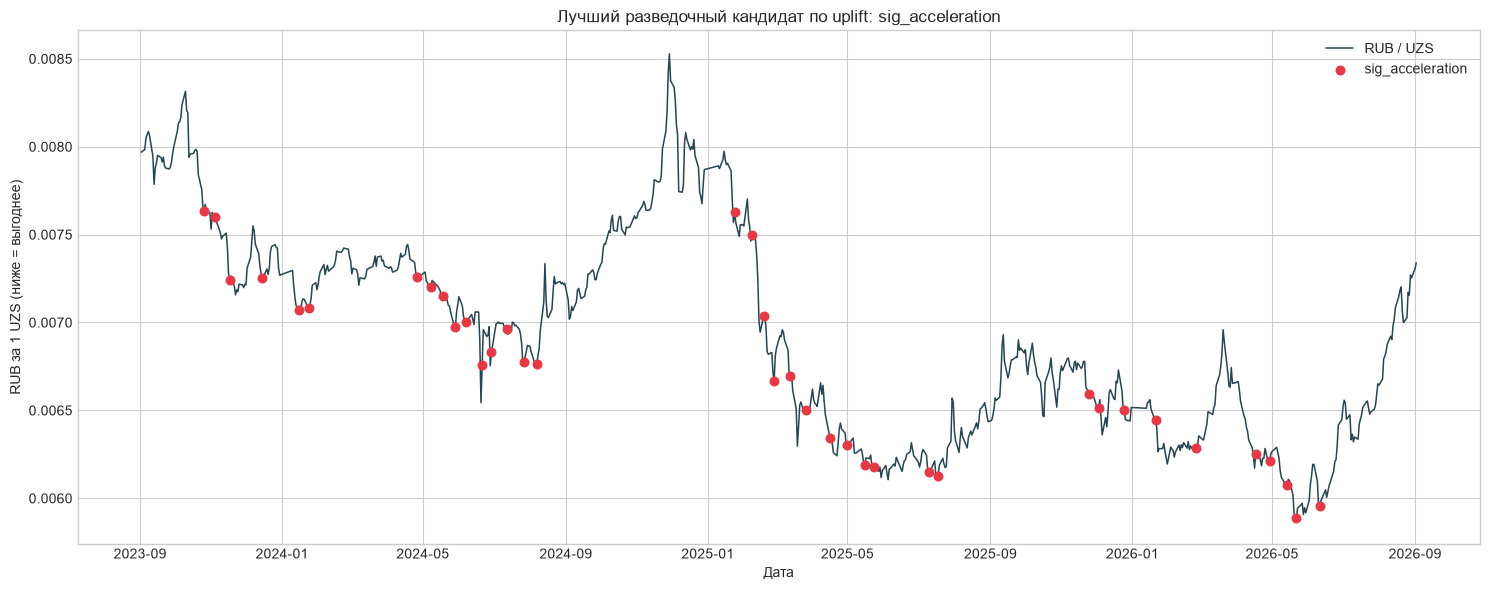

In [11]:
best_signal = exploration_results.dropna(subset=['uplift_vs_random']).iloc[0]['signal']
plot_period = df[df['data'] >= df['data'].max() - pd.DateOffset(years=3)].copy()
points = plot_period[plot_period[f'{best_signal}_cooldown']]

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(plot_period['data'], plot_period['rub_per_uzs'], color='#264653', lw=1.1, label='RUB / UZS')
ax.scatter(points['data'], points['rub_per_uzs'], color='#E63946', s=38, zorder=3, label=best_signal)
ax.set_title(f'Лучший разведочный кандидат по uplift: {best_signal}')
ax.set_ylabel('RUB за 1 UZS (ниже = выгоднее)')
ax.set_xlabel('Дата')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Корреляции и рекомендации для следующего шага

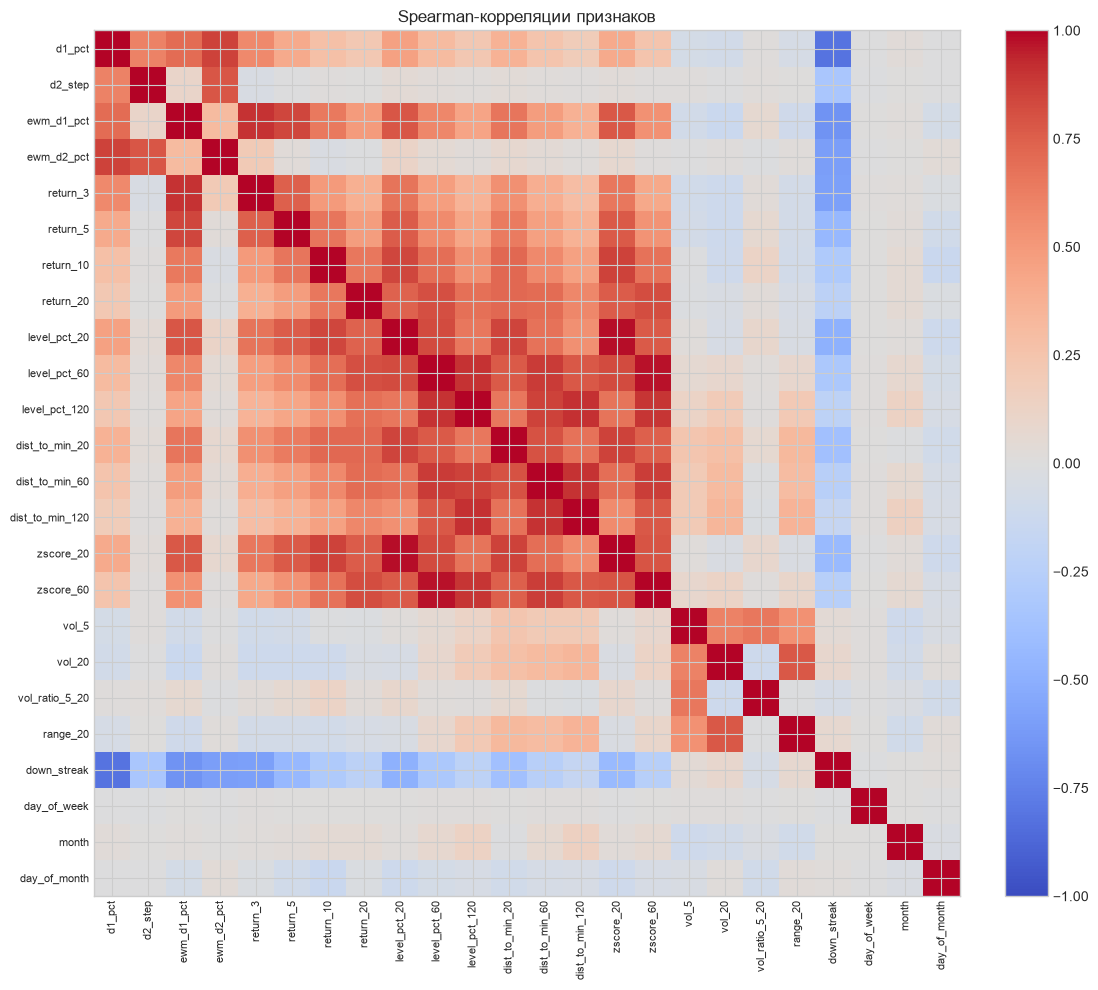

,spearman_with_hit
vol_20,-0.116772
vol_5,-0.112876
level_pct_60,0.108860
range_20,-0.100518
d1_pct,0.095126
level_pct_20,0.094299
zscore_60,0.093237
return_20,0.091382
dist_to_min_60,0.089925
zscore_20,0.085523


In [12]:
model_features = [
    'd1_pct', 'd2_step', 'ewm_d1_pct', 'ewm_d2_pct',
    'return_3', 'return_5', 'return_10', 'return_20',
    'level_pct_20', 'level_pct_60', 'level_pct_120',
    'dist_to_min_20', 'dist_to_min_60', 'dist_to_min_120',
    'zscore_20', 'zscore_60', 'vol_5', 'vol_20', 'vol_ratio_5_20',
    'range_20', 'down_streak', 'day_of_week', 'month', 'day_of_month',
]
corr = df[model_features].corr(method='spearman')
fig, ax = plt.subplots(figsize=(12, 10))
image = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(model_features)), model_features, rotation=90, fontsize=8)
ax.set_yticks(range(len(model_features)), model_features, fontsize=8)
ax.set_title('Spearman-корреляции признаков')
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

valid = df['label_is_valid']
ranked_features = df.loc[valid, model_features].rank(method='average')
ranked_target = df.loc[valid, 'hit_good_now_h5'].astype(float).rank(method='average')
target_corr = (ranked_features.corrwith(ranked_target, method='pearson')
                 .sort_values(key=np.abs, ascending=False)
                 .rename('spearman_with_hit'))
display(target_corr.to_frame().head(15))

In [13]:
latest_features = df[['data', 'rub_per_uzs', 'uzs_per_rub'] + model_features + signal_columns].tail(30).copy()
latest_features.to_csv('data/UZS_features_latest_30.csv', index=False)

print('Итоги разведки')
print('---------------')
print(f'Период: {df.data.min().date()} — {df.data.max().date()}, наблюдений: {len(df)}')
print(f'Лучший разведочный кандидат: {best_signal}')
print('Файл последних 30 строк признаков: data/UZS_features_latest_30.csv')
print()
print('Что делать дальше:')
print('1. Заморозить h и epsilon вместе с продуктовой частью.')
print('2. Перенести пороги сигналов в train/calibration часть walk-forward.')
print('3. Сравнить Logistic Regression и Gradient Boosting с базовыми индикаторами.')
print('4. Посчитать метрики отдельно по OOT-folds; средняя по всей истории недостаточна.')
print('5. Отдельно оценить fast/slow: d1/acceleration против подтверждённого level/reversal.')

Итоги разведки
---------------
Период: 2016-09-02 — 2026-09-02, наблюдений: 2468
Лучший разведочный кандидат: sig_acceleration
Файл последних 30 строк признаков: data/UZS_features_latest_30.csv

Что делать дальше:
1. Заморозить h и epsilon вместе с продуктовой частью.
2. Перенести пороги сигналов в train/calibration часть walk-forward.
3. Сравнить Logistic Regression и Gradient Boosting с базовыми индикаторами.
4. Посчитать метрики отдельно по OOT-folds; средняя по всей истории недостаточна.
5. Отдельно оценить fast/slow: d1/acceleration против подтверждённого level/reversal.
